# Phase 1: Preprocessing CICIDS2017 Dataset

In [15]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
RAW_DIR = "/kaggle/input/datasets/sateeshkumar6289/cicids-2017-dataset"
OUT_DIR = "/kaggle/working/processed" 

In [17]:
#a new directory will be craete where we will stor the output dataset after cleaning it.
os.makedirs(OUT_DIR, exist_ok=True)

In [18]:
# STEP 1: Load and combine the CSV files
csv_paths = glob.glob(os.path.join(RAW_DIR, "*.csv"))
df_list = [pd.read_csv(path, low_memory=False, encoding="latin1") for path in csv_paths]
df = pd.concat(df_list)
df = df.reset_index(drop=True)
print("Combined shape:", df.shape)

Combined shape: (2830743, 79)


In [19]:
# STEP 2: Clean column names (strip stray whitespace)
df.columns = df.columns.str.strip()

In [20]:
# STEP 3: Identify the label column
label_col = "Label"
print("Label column:", label_col)
print(df[label_col].value_counts())#gives the total number rows which contains that attacks 


Label column: Label
Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


In [21]:
# STEP 4: Remove duplicate rows (before the split, to avoid the leakage)
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

Duplicates: 308381
Shape after dedup: (2522362, 79)


In [22]:
# STEP 5: Handle infinite and missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print("Rows with missing values:", df[numeric_cols].isna().any(axis=1).sum())
df = df.dropna(subset=numeric_cols)
print("Shape after dropping missing rows:", df.shape)

Rows with missing values: 1564
Shape after dropping missing rows: (2520798, 79)


In [23]:
# STEP 6: Drop identifier / leakage-risk columns becuse the 
#model will not learn from attack categories and will jsut memorise the dataset
id_cols = ["Flow ID", "Source IP", "Src IP", "Destination IP", "Dst IP", "Timestamp"]
df = df.drop(columns=[c for c in id_cols if c in df.columns])

In [24]:
# STEP 7: Drop constant (zero-variance) columns because they contribute nothing to the training
numeric_cols = df.select_dtypes(include=[np.number]).columns  # recompute after drops
constant_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
df = df.drop(columns=constant_cols)
print("Dropped constant columns:", constant_cols)

Dropped constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [25]:
# STEP 8: Build the labels
# 2 kinds of lables
# 1. binary label: benign=0,maliciou=1
# 2. attack category: the specific attack
df[label_col] = df[label_col].astype(str).str.strip()
df["Binary_Label"] = (df[label_col] != "BENIGN").astype(int)
df["Attack_Category"] = df[label_col]
df = df.drop(columns=[label_col])
print("\nClass distribution:")
print(df["Attack_Category"].value_counts())
#the below data shows each attack category occupies how many rows in the datset


Class distribution:
Attack_Category
BENIGN                          2095057
DoS Hulk                         172846
DDoS                             128014
PortScan                          90694
DoS GoldenEye                     10286
FTP-Patator                        5931
DoS slowloris                      5385
DoS Slowhttptest                   5228
SSH-Patator                        3219
Bot                                1948
Web Attack ï¿½ Brute Force         1470
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


In [26]:
# STEP 9: Separate features/labels, then train/test split
feature_cols = [c for c in df.columns if c not in ("Binary_Label", "Attack_Category")]
X = df[feature_cols]
y = df["Binary_Label"]

X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y, df["Attack_Category"],
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])


Train rows: 2016638 | Test rows: 504160


In [27]:
# STEP 10: Scale features (fit on train only, apply to test)
# we are scaling here becuase one column may be in millions and the other is represented using only number
#if there is a huge diffrence in the numbers then the model will get confused
#that is why we just scale to some similar avalues 
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

In [28]:

# STEP 11: Save processed data
X_train_scaled["Binary_Label"] = y_train.values
X_train_scaled["Attack_Category"] = cat_train.values

X_test_scaled["Binary_Label"] = y_test.values
X_test_scaled["Attack_Category"] = cat_test.values

X_train_scaled.to_csv(os.path.join(OUT_DIR, "train.csv"), index=False)
X_test_scaled.to_csv(os.path.join(OUT_DIR, "test.csv"), index=False)

print("\nSaved train.csv and test.csv to", OUT_DIR)


Saved train.csv and test.csv to /kaggle/working/processed


In [29]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

/kaggle/working/processed/train.csv
/kaggle/working/processed/test.csv


# Phase 2: EDA 

In [30]:
#Exploratory traffic analysis : to knwo about how dat is distributed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


TRAIN_FILE = "/kaggle/working/processed/train.csv"


# Load the preprocessed training data
df = pd.read_csv(TRAIN_FILE)
print("Loaded data with shape:", df.shape)
print()

Loaded data with shape: (2016638, 72)



In [31]:
# PART 1: Class distribution - how imbalanced is the data?
print("=" * 60)
print("PART 1: Class Distribution")
print("=" * 60)

# Count how many Normal (0) vs Attack (1) rows we have
binary_counts = df["Binary_Label"].value_counts()
print("\nNormal vs Attack counts:")
print(binary_counts)

# Show the same thing as a percentage, easier to understand imbalance
binary_percent = df["Binary_Label"].value_counts(normalize=True) * 100
print("\nNormal vs Attack percentage:")
print(binary_percent.round(2))

# Count each individual attack category too
print("\nCounts per attack category:")
print(df["Attack_Category"].value_counts())

# Make a simple bar chart of attack categories
plt.figure(figsize=(10, 5))
df["Attack_Category"].value_counts().plot(kind="bar")
plt.title("Number of Flows per Attack Category")
plt.ylabel("Number of flows")
plt.xlabel("Category")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.close()
print("\nSaved chart: class_distribution.png")
#from the output you can see that 83% is normal data and the other nearly 17% is attack category. this shows class imbalance

PART 1: Class Distribution

Normal vs Attack counts:
Binary_Label
0    1676045
1     340593
Name: count, dtype: int64

Normal vs Attack percentage:
Binary_Label
0    83.11
1    16.89
Name: proportion, dtype: float64

Counts per attack category:
Attack_Category
BENIGN                          1676045
DoS Hulk                         138165
DDoS                             102335
PortScan                          72722
DoS GoldenEye                      8318
FTP-Patator                        4724
DoS slowloris                      4284
DoS Slowhttptest                   4242
SSH-Patator                        2530
Bot                                1571
Web Attack ï¿½ Brute Force         1136
Web Attack ï¿½ XSS                  511
Infiltration                         29
Web Attack ï¿½ Sql Injection         18
Heartbleed                            8
Name: count, dtype: int64

Saved chart: class_distribution.png


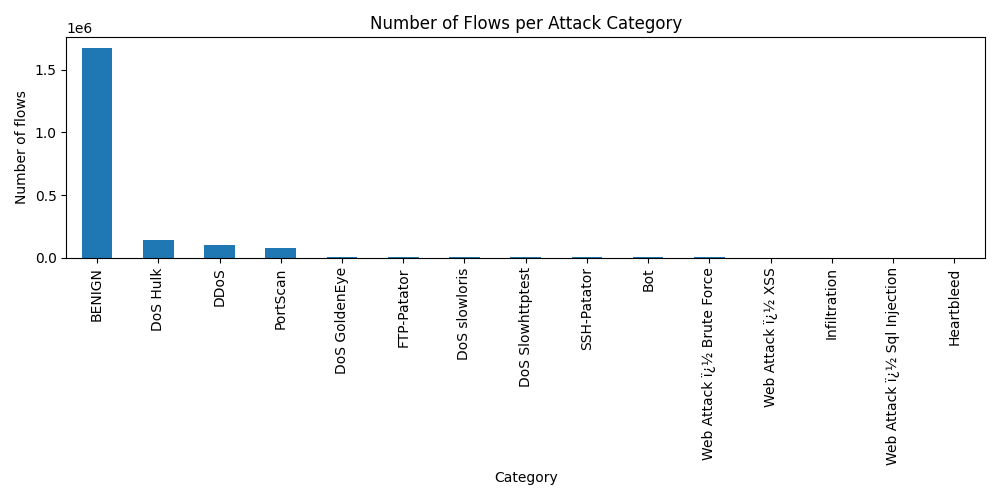

In [33]:
from IPython.display import Image, display
display(Image("/kaggle/working/class_distribution.png"))

In [32]:
  import os
  print(os.listdir("/kaggle/working"))

['processed', 'class_distribution.png', '.virtual_documents']


In [34]:
# PART 2: Compare a few key features between Normal and Attack traffic
print("\n" + "=" * 60)
print("PART 2: Normal vs Attack - Feature Comparison")
print("=" * 60)

# Pick a small number of important features to look at.

features_to_check = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
]

# keep only the features that actually exist in this dataset
features_to_check = [f for f in features_to_check if f in df.columns]
print("\nFeatures being compared:", features_to_check)
# For each feature, print the average value for Normal vs Attack rows
for feature in features_to_check:
    normal_avg = df[df["Binary_Label"] == 0][feature].mean()
    attack_avg = df[df["Binary_Label"] == 1][feature].mean()
    print(f"\n{feature}:")
    print(f"   Normal average: {normal_avg:.4f}")
    print(f"   Attack average: {attack_avg:.4f}")

# Now make a boxplot for each feature, comparing Normal vs Attack side by side
for feature in features_to_check:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=feature, by="Binary_Label")
    plt.title(f"{feature}: Normal (0) vs Attack (1)")
    plt.suptitle("")  # removes the default ugly subtitle
    plt.xlabel("Binary_Label (0 = Normal, 1 = Attack)")
    plt.ylabel(feature)
    plt.tight_layout()
    safe_name = feature.replace("/", "_").replace(" ", "_")
    plt.savefig(f"boxplot_{safe_name}.png")
    plt.close()

print("\nSaved one boxplot image per feature (boxplot_<feature>.png)")



PART 2: Normal vs Attack - Feature Comparison

Features being compared: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Flow Bytes/s', 'Flow Packets/s']

Flow Duration:
   Normal average: -0.1256
   Attack average: 0.6178

Total Fwd Packets:
   Normal average: 0.0014
   Attack average: -0.0068

Total Backward Packets:
   Normal average: 0.0014
   Attack average: -0.0071

Flow Bytes/s:
   Normal average: 0.0099
   Attack average: -0.0489

Flow Packets/s:
   Normal average: 0.0308
   Attack average: -0.1518

Saved one boxplot image per feature (boxplot_<feature>.png)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [37]:
import os
print(os.listdir("/kaggle/working"))

['boxplot_Total_Fwd_Packets.png', 'boxplot_Flow_Duration.png', 'boxplot_Flow_Bytes_s.png', 'processed', 'boxplot_Total_Backward_Packets.png', 'class_distribution.png', 'boxplot_Flow_Packets_s.png', '.virtual_documents']


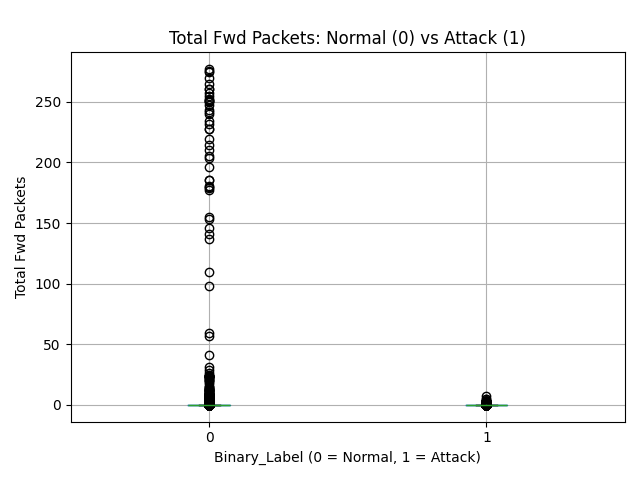

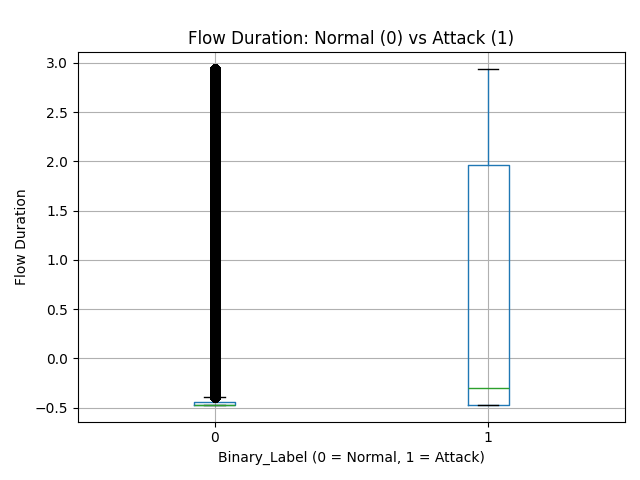

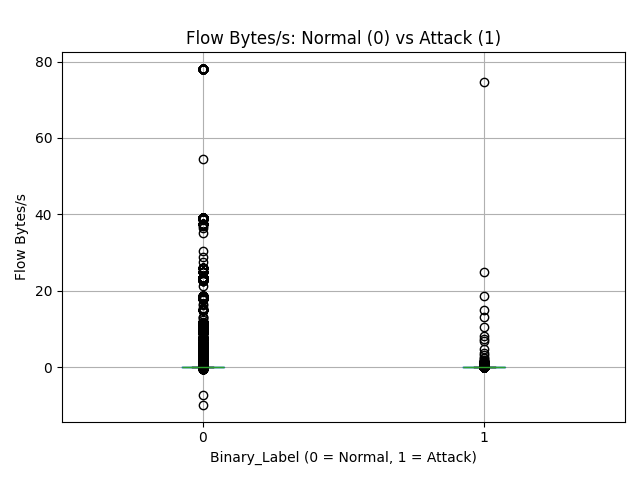

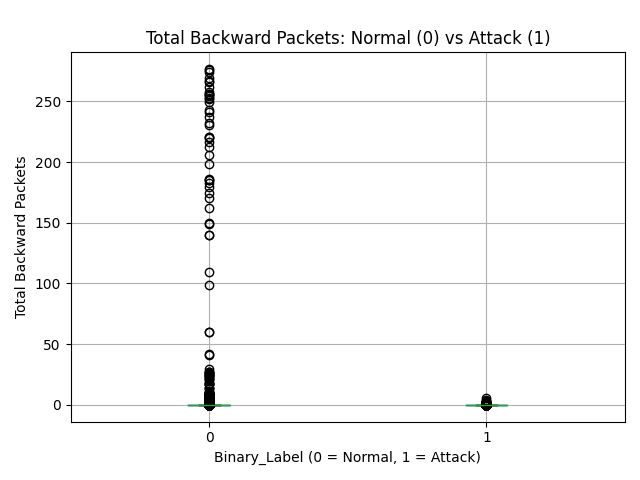

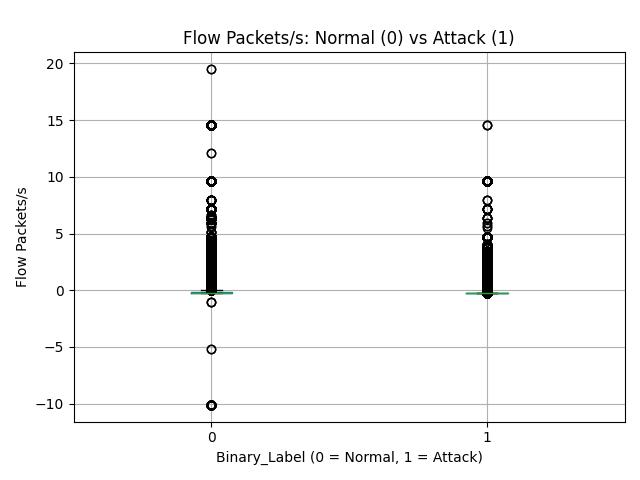

In [39]:
from IPython.display import Image, display
display(Image("/kaggle/working/boxplot_Total_Fwd_Packets.png"))
display(Image("/kaggle/working/boxplot_Flow_Duration.png"))
display(Image("/kaggle/working/boxplot_Flow_Bytes_s.png"))
display(Image("/kaggle/working/boxplot_Total_Backward_Packets.png"))
display(Image("/kaggle/working/boxplot_Flow_Packets_s.png"))

In [40]:
# PART 3: Compare features ACROSS different attack categories
print("\n" + "=" * 60)
print("PART 3: Comparing Attack Categories to Each Other")
print("=" * 60)

# We take the top 5 most common categories (this usually includes BENIGN).
top_categories = df["Attack_Category"].value_counts().head(6).index.tolist()
print("\nTop categories being compared:", top_categories)

df_top = df[df["Attack_Category"].isin(top_categories)]

for feature in features_to_check:
    plt.figure(figsize=(8, 5))
    df_top.boxplot(column=feature, by="Attack_Category", rot=45)
    plt.title(f"{feature} across top attack categories")
    plt.suptitle("")
    plt.ylabel(feature)
    plt.tight_layout()
    safe_name = feature.replace("/", "_").replace(" ", "_")
    plt.savefig(f"category_boxplot_{safe_name}.png")
    plt.close()

print("\nSaved one boxplot per feature comparing categories (category_boxplot_<feature>.png)")


PART 3: Comparing Attack Categories to Each Other

Top categories being compared: ['BENIGN', 'DoS Hulk', 'DDoS', 'PortScan', 'DoS GoldenEye', 'FTP-Patator']

Saved one boxplot per feature comparing categories (category_boxplot_<feature>.png)


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [41]:
import os
print(os.listdir("/kaggle/working"))

['boxplot_Total_Fwd_Packets.png', 'category_boxplot_Total_Fwd_Packets.png', 'boxplot_Flow_Duration.png', 'category_boxplot_Total_Backward_Packets.png', 'boxplot_Flow_Bytes_s.png', 'processed', 'category_boxplot_Flow_Duration.png', 'category_boxplot_Flow_Packets_s.png', 'boxplot_Total_Backward_Packets.png', 'class_distribution.png', 'boxplot_Flow_Packets_s.png', '.virtual_documents', 'category_boxplot_Flow_Bytes_s.png']


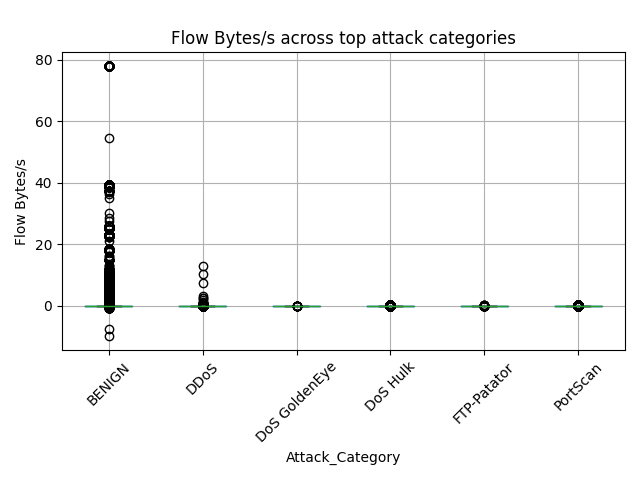

In [42]:
from IPython.display import Image, display
display(Image("/kaggle/working/category_boxplot_Flow_Bytes_s.png"))

In [44]:
# PART 4: Correlation heatmap - find features that repeat the same info
print("\n" + "=" * 60)
print("PART 4: Correlation Between Features")
print("=" * 60)

# Only use numeric columns, and exclude the label columns
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.drop(columns=["Binary_Label"], errors="ignore")

# To keep the heatmap readable, only look at the first 20 numeric columns
columns_to_plot = numeric_df.columns[:20]
correlation_matrix = numeric_df[columns_to_plot].corr()

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(columns_to_plot)), columns_to_plot, rotation=90)
plt.yticks(range(len(columns_to_plot)), columns_to_plot)
plt.title("Correlation Heatmap (first 20 numeric features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.close()
print("\nSaved chart: correlation_heatmap.png")

# Print out any pair of features that are VERY highly correlated (>0.9)
print("\nHighly correlated feature pairs (correlation > 0.9):")
already_shown = set()
for col1 in correlation_matrix.columns:
    for col2 in correlation_matrix.columns:
        if col1 != col2:
            pair = tuple(sorted([col1, col2]))
            corr_value = correlation_matrix.loc[col1, col2]
            if abs(corr_value) > 0.9 and pair not in already_shown:
                print(f"   {col1}  <->  {col2}   correlation = {corr_value:.2f}")
                already_shown.add(pair)



PART 4: Correlation Between Features

Saved chart: correlation_heatmap.png

Highly correlated feature pairs (correlation > 0.9):
   Total Fwd Packets  <->  Total Backward Packets   correlation = 1.00
   Total Fwd Packets  <->  Total Length of Bwd Packets   correlation = 1.00
   Total Backward Packets  <->  Total Length of Bwd Packets   correlation = 0.99
   Fwd Packet Length Max  <->  Fwd Packet Length Std   correlation = 0.97
   Bwd Packet Length Max  <->  Bwd Packet Length Mean   correlation = 0.96
   Bwd Packet Length Max  <->  Bwd Packet Length Std   correlation = 0.98
   Bwd Packet Length Mean  <->  Bwd Packet Length Std   correlation = 0.94
   Flow IAT Std  <->  Flow IAT Max   correlation = 0.94


In [45]:

# PART 5: Check if any feature separates Attack vs Normal TOO perfectly
print("\n" + "=" * 60)
print("PART 5: Checking for Suspiciously Perfect Features")
print("=" * 60)
print("If a feature separates Normal/Attack almost perfectly, investigate")
print("why - it might be a real signal, or a data collection artifact.\n")

for feature in features_to_check:
    normal_values = df[df["Binary_Label"] == 0][feature]
    attack_values = df[df["Binary_Label"] == 1][feature]

    normal_max = normal_values.max()
    normal_min = normal_values.min()
    attack_max = attack_values.max()
    attack_min = attack_values.min()

    # If the value ranges for Normal and Attack don't overlap at all,
    # this feature ALONE can perfectly tell them apart - worth investigating.
    no_overlap = (normal_max < attack_min) or (attack_max < normal_min)

    print(f"{feature}:")
    print(f"   Normal range: {normal_min:.2f} to {normal_max:.2f}")
    print(f"   Attack range: {attack_min:.2f} to {attack_max:.2f}")
    if no_overlap:
        print("   WARNING: ranges do not overlap at all - investigate this feature!")
    print()

print("Done with Phase 2. Check the saved .png images in this folder.")


PART 5: Checking for Suspiciously Perfect Features
If a feature separates Normal/Attack almost perfectly, investigate
why - it might be a real signal, or a data collection artifact.

Flow Duration:
   Normal range: -0.47 to 2.94
   Attack range: -0.47 to 2.94

Total Fwd Packets:
   Normal range: -0.01 to 277.07
   Attack range: -0.01 to 6.95

Total Backward Packets:
   Normal range: -0.01 to 276.56
   Attack range: -0.01 to 5.22

Flow Bytes/s:
   Normal range: -9.89 to 78.03
   Attack range: -0.05 to 74.60

Flow Packets/s:
   Normal range: -10.09 to 19.49
   Attack range: -0.23 to 14.56

Done with Phase 2. Check the saved .png images in this folder.


In [46]:
import os
print(os.listdir("/kaggle/working"))

['boxplot_Total_Fwd_Packets.png', 'category_boxplot_Total_Fwd_Packets.png', 'boxplot_Flow_Duration.png', 'category_boxplot_Total_Backward_Packets.png', 'boxplot_Flow_Bytes_s.png', 'processed', 'category_boxplot_Flow_Duration.png', 'category_boxplot_Flow_Packets_s.png', 'boxplot_Total_Backward_Packets.png', 'class_distribution.png', 'correlation_heatmap.png', 'boxplot_Flow_Packets_s.png', '.virtual_documents', 'category_boxplot_Flow_Bytes_s.png']


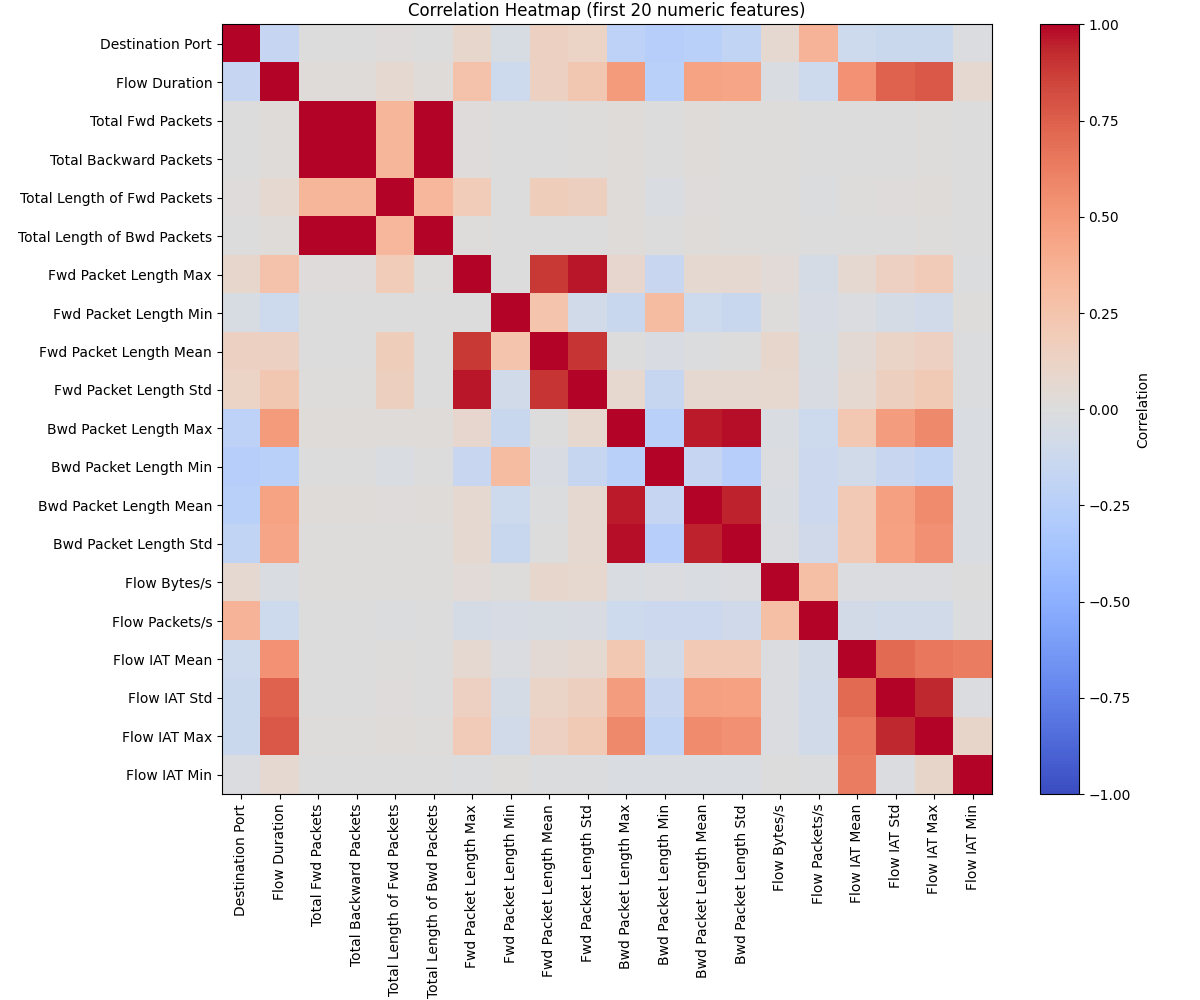

In [47]:
from IPython.display import Image, display
display(Image("/kaggle/working/correlation_heatmap.png"))

In [26]:
import os
print(os.listdir("."))

['correlation_heatmap.png', 'boxplot_Flow_Packets_s.png', 'class_distribution.png', 'boxplot_Total_Backward_Packets.png', 'category_boxplot_Total_Fwd_Packets.png', 'boxplot_Total_Fwd_Packets.png', 'processed', 'category_boxplot_Flow_Bytes_s.png', 'boxplot_Flow_Duration.png', 'category_boxplot_Flow_Packets_s.png', 'boxplot_Flow_Bytes_s.png', 'category_boxplot_Flow_Duration.png', '.virtual_documents', 'category_boxplot_Total_Backward_Packets.png']


# Phase 3: Training the models

In [48]:
import pandas as pd
import numpy as np
import time
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
 
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
)


 
TRAIN_FILE = "/kaggle/working/processed/train.csv"
TEST_FILE = "/kaggle/working/processed/test.csv"
 

In [49]:
# STEP 1: Load the preprocessed train and test data
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
 
# STEP 2: Separate features (X) from the target (y)
# We only need Binary_Label for this phase - Attack_Category is for Phase 4
columns_to_drop = ["Binary_Label", "Attack_Category"]
 
X_train = train_df.drop(columns=columns_to_drop)
y_train = train_df["Binary_Label"]
 
X_test = test_df.drop(columns=columns_to_drop)
y_test = test_df["Binary_Label"]
 
print("Number of features used:", X_train.shape[1])

Train shape: (2016638, 72)
Test shape: (504160, 72)
Number of features used: 70


In [50]:
#STEP 3: A helper function that trains one model and prints ALL the
# security-relevant metrics your project guide asks for.
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    print("\n" + "=" * 60)
    print("MODEL:", model_name)
    print("=" * 60)
 
    #  Train the model, and time how long it takes 
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
 
    # Predict on the test set, and time this too 
    start_time = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time
 
    # Get predicted probabilities (needed for ROC-AUC) 
    # predict_proba gives two columns: [probability of 0, probability of 1]
    # we only want the probability of class 1 (Attack)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
 
    #  Core metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
 
    #  Confusion matrix
    # This gives us: true negatives, false positives, false negatives, true positives
    cm = confusion_matrix(y_test, y_pred)
    true_negative, false_positive, false_negative, true_positive = cm.ravel()
 
    # False Positive Rate
    # FPR = how many Normal flows were wrongly flagged as attacks
    # out of ALL the actual Normal flows
    false_positive_rate = false_positive / (false_positive + true_negative)
 
    # Print everything 
    print(f"Training time:      {training_time:.2f} seconds")
    print(f"Prediction time:     {prediction_time:.4f} seconds")
    print(f"Precision:           {precision:.4f}")
    print(f"Recall:              {recall:.4f}  (this is your attack detection rate)")
    print(f"F1-score:            {f1:.4f}")
    print(f"False Positive Rate: {false_positive_rate:.4f}")
    print(f"ROC-AUC:             {roc_auc:.4f}")
 
    print("\nConfusion Matrix:")
    print("                  Predicted Normal   Predicted Attack")
    print(f"Actual Normal        {true_negative:>10}         {false_positive:>10}")
    print(f"Actual Attack        {false_negative:>10}         {true_positive:>10}")
 
    print("\nFull classification report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"]))
 
    # return the results so we can compare models at the end
    return {
        "model_name": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "roc_auc": roc_auc,
        "training_time": training_time,
        "prediction_time": prediction_time,
    }
 
 

In [51]:
# STEP 4: Train and evaluate all three models
results = []
 
#  Model 1: Logistic Regression (simple baseline) 
log_reg_model = LogisticRegression(max_iter=1000)
results.append(
    train_and_evaluate(log_reg_model, "Logistic Regression", X_train, y_train, X_test, y_test)
)
 
# Model 2: Random Forest (tree-based baseline) 
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results.append(
    train_and_evaluate(random_forest_model, "Random Forest", X_train, y_train, X_test, y_test)
)
 
# ---- Model 3: XGBoost (primary model) ----
xgboost_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)
results.append(
    train_and_evaluate(xgboost_model, "XGBoost", X_train, y_train, X_test, y_test)
)
 
 
# STEP 5: Put all results side by side so you can compare models easily
print("\n" + "=" * 60)
print("SUMMARY: All Models Compared")
print("=" * 60)
 
results_df = pd.DataFrame(results)
results_df = results_df.set_index("model_name")
print(results_df.round(4))
 
results_df.to_csv("phase3_model_comparison.csv")
print("\nSaved comparison table to: phase3_model_comparison.csv")
 
print("\nDone with Phase 3 baseline evaluation.")



MODEL: Logistic Regression
Training time:      124.48 seconds
Prediction time:     0.0813 seconds
Precision:           0.8819
Recall:              0.8607  (this is your attack detection rate)
F1-score:            0.8712
False Positive Rate: 0.0234
ROC-AUC:             0.9883

Confusion Matrix:
                  Predicted Normal   Predicted Attack
Actual Normal            409194               9818
Actual Attack             11860              73288

Full classification report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97    419012
      Attack       0.88      0.86      0.87     85148

    accuracy                           0.96    504160
   macro avg       0.93      0.92      0.92    504160
weighted avg       0.96      0.96      0.96    504160


MODEL: Random Forest
Training time:      556.04 seconds
Prediction time:     3.3708 seconds
Precision:           0.9963
Recall:              0.9950  (this is your attack detection rate)
F1-sc

# Phase 4: Multiclass Attack Classification

In [52]:
import pandas as pd
import numpy as np
 
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier



TRAIN_FILE = "/kaggle/working/processed/train.csv"
TEST_FILE = "/kaggle/working/processed/test.csv"

 
# STEP 1: Load the preprocessed data
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (2016638, 72)
Test shape: (504160, 72)


In [53]:
print("\nCategory counts in training data:")
category_counts = train_df["Attack_Category"].value_counts()
print(category_counts)
 
# Set a minimum sample threshold. Categories with fewer training rows than
# this get EXCLUDED from multiclass training (they cannot be reliably
# learned or evaluated with so few examples).
MIN_SAMPLES = 50

 
categories_to_keep = category_counts[category_counts >= MIN_SAMPLES].index.tolist()
categories_dropped = category_counts[category_counts < MIN_SAMPLES].index.tolist()
 
print(f"\nKeeping {len(categories_to_keep)} categories with >= {MIN_SAMPLES} samples")
print("Categories kept:", categories_to_keep)
print("Categories dropped (too rare for reliable multiclass modelling):", categories_dropped)


Category counts in training data:
Attack_Category
BENIGN                          1676045
DoS Hulk                         138165
DDoS                             102335
PortScan                          72722
DoS GoldenEye                      8318
FTP-Patator                        4724
DoS slowloris                      4284
DoS Slowhttptest                   4242
SSH-Patator                        2530
Bot                                1571
Web Attack ï¿½ Brute Force         1136
Web Attack ï¿½ XSS                  511
Infiltration                         29
Web Attack ï¿½ Sql Injection         18
Heartbleed                            8
Name: count, dtype: int64

Keeping 12 categories with >= 50 samples
Categories kept: ['BENIGN', 'DoS Hulk', 'DDoS', 'PortScan', 'DoS GoldenEye', 'FTP-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'SSH-Patator', 'Bot', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']
Categories dropped (too rare for reliable multiclass modelling): ['Infiltratio

In [54]:
train_filtered = train_df[train_df["Attack_Category"].isin(categories_to_keep)]
test_filtered = test_df[test_df["Attack_Category"].isin(categories_to_keep)]
 
print("\nTrain shape after filtering rare categories:", train_filtered.shape)
print("Test shape after filtering rare categories:", test_filtered.shape)
 
 
# STEP 4: Prepare features (X) and multiclass target (y)
columns_to_drop = ["Binary_Label", "Attack_Category"]
 
X_train = train_filtered.drop(columns=columns_to_drop)
X_test = test_filtered.drop(columns=columns_to_drop)
 
# XGBoost needs numeric labels, not text like "DDoS" or "BENIGN".
# LabelEncoder converts each category name into a number (0, 1, 2, ...)
label_encoder = LabelEncoder()
label_encoder.fit(train_filtered["Attack_Category"])
 
y_train = label_encoder.transform(train_filtered["Attack_Category"])
y_test = label_encoder.transform(test_filtered["Attack_Category"])
 
# Keep the mapping so we can turn numbers back into readable names later
class_names = label_encoder.classes_
print("\nClass number -> Category name mapping:")
for number, name in enumerate(class_names):
    print(f"   {number} -> {name}")
 
 
# STEP 5: Train the multiclass XGBoost model
print("\nTraining multiclass XGBoost model...")
 
multiclass_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1,
)
multiclass_model.fit(X_train, y_train)
 
y_pred = multiclass_model.predict(X_test)
print("Training complete.")


Train shape after filtering rare categories: (2016583, 72)
Test shape after filtering rare categories: (504147, 72)

Class number -> Category name mapping:
   0 -> BENIGN
   1 -> Bot
   2 -> DDoS
   3 -> DoS GoldenEye
   4 -> DoS Hulk
   5 -> DoS Slowhttptest
   6 -> DoS slowloris
   7 -> FTP-Patator
   8 -> PortScan
   9 -> SSH-Patator
   10 -> Web Attack ï¿½ Brute Force
   11 -> Web Attack ï¿½ XSS

Training multiclass XGBoost model...
Training complete.


In [55]:
#STEP 6: Multiclass confusion matrix
print("\n" + "=" * 60)
print("Multiclass Confusion Matrix")
print("=" * 60)
 
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(cm_df)
 
cm_df.to_csv("phase4_confusion_matrix.csv")
print("\nSaved confusion matrix to: phase4_confusion_matrix.csv")
"""
How to read this table:
Rows = the ACTUAL category
Columns = what the model PREDICTED
Numbers on the diagonal = correct predictions
Numbers off the diagonal = confusions (e.g. row=DDoS, column=BENIGN
means some real DDoS flows were predicted as BENIGN)
"""

# STEP 7: Per-class precision, recall, F1-score
print("\n" + "=" * 60)
print("Per-Class Performance")
print("=" * 60)
 
report_text = classification_report(y_test, y_pred, target_names=class_names)
print(report_text)
 
# Also save this as a proper table (easier to sort and inspect than plain text)
report_dict = classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("phase4_per_class_report.csv")
print("Saved per-class report to: phase4_per_class_report.csv")
 
 
# STEP 8: Highlight the best and worst detected categories
print("\n" + "=" * 60)
print("Best and Worst Detected Categories (by Recall)")
print("=" * 60)
 
# Only look at the actual class rows, not the summary rows
# (classification_report adds extra rows like "accuracy", "macro avg", etc.)
class_only_report = report_df.drop(
    index=[r for r in report_df.index if r not in class_names]
)
class_only_report = class_only_report.sort_values("recall", ascending=False)
 
print("\nBest detected categories (highest recall):")
print(class_only_report[["precision", "recall", "f1-score", "support"]].head(5))
 
print("\nWorst detected categories (lowest recall):")
print(class_only_report[["precision", "recall", "f1-score", "support"]].tail(5))
 
print("\nDone with Phase 4.")



Multiclass Confusion Matrix
                            BENIGN  Bot   DDoS  DoS GoldenEye  DoS Hulk  \
BENIGN                      413729  527    527            607      1116   
Bot                            270   97      0              0        10   
DDoS                           312    3  24493             26        72   
DoS GoldenEye                  156    0     42           1740        28   
DoS Hulk                       602    1     21             20     33913   
DoS Slowhttptest                83    0      0              2         0   
DoS slowloris                  223    0    119              0        32   
FTP-Patator                    390    0      0              0         0   
PortScan                       358  174      9              8        15   
SSH-Patator                     49    0      0              0         0   
Web Attack ï¿½ Brute Force      59    0      0              0         1   
Web Attack ï¿½ XSS              13    0      0              1         1